In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load dataset Titanic
df = sns.load_dataset("titanic")

# Ukuran data
print("Ukuran Data:", df.shape)

# Tipe kolom
print("\nTipe Kolom:")
print(df.dtypes)

Ukuran Data: (891, 15)

Tipe Kolom:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [26]:
print("\nMissing Value Sebelum:")
print(df.isnull().sum())

# age → median (karena numerik & tahan outlier)
df["age"] = df["age"].fillna(df["age"].median())

# embarked → modus (karena kategorikal)
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# deck → dihapus karena terlalu banyak missing (>70%)
df = df.drop(columns=["deck"])

print("\nMissing Value Sesudah:")
print(df.isnull().sum())


Missing Value Sebelum:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing Value Sesudah:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


In [27]:

# OUTLIER HANDLING (IQR)

# Fare
q1, q3 = df["fare"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
df["fare"] = df["fare"].clip(low, high)

# Age
q1_age, q3_age = df["age"].quantile([0.25, 0.75])
iqr_age = q3_age - q1_age
low_age, high_age = q1_age - 1.5*iqr_age, q3_age + 1.5*iqr_age
df["age"] = df["age"].clip(low_age, high_age)

print("=== DESKRIPSI DATA SETELAH OUTLIER HANDLING ===")
print(df[["age", "fare"]].describe())

=== DESKRIPSI DATA SETELAH OUTLIER HANDLING ===
              age        fare
count  891.000000  891.000000
mean    29.039282   24.046813
std     12.072074   20.481625
min      2.500000    0.000000
25%     22.000000    7.910400
50%     28.000000   14.454200
75%     35.000000   31.000000
max     54.500000   65.634400


In [28]:
# SCALING (STANDARDIZATION)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["age", "fare"]] = scaler.fit_transform(df[["age", "fare"]])

print("=== DESKRIPSI DATA SETELAH SCALING ===")
print(df[["age", "fare"]].describe())

=== DESKRIPSI DATA SETELAH SCALING ===
                age          fare
count  8.910000e+02  8.910000e+02
mean   2.392400e-17  9.968332e-17
std    1.000562e+00  1.000562e+00
min   -2.199638e+00 -1.174727e+00
25%   -5.834321e-01 -7.882908e-01
50%   -8.613809e-02 -4.686152e-01
75%    4.940382e-01  3.396748e-01
max    2.110244e+00  2.031623e+00


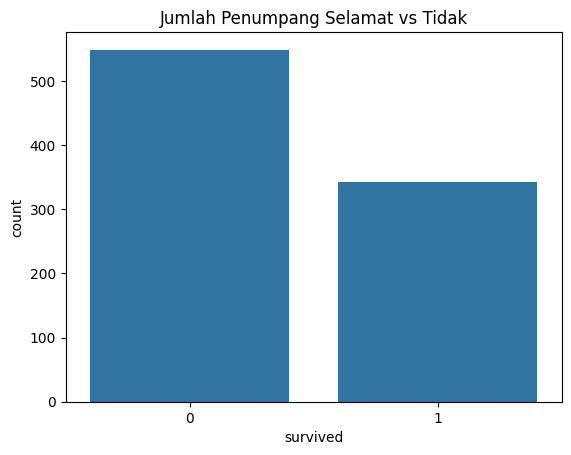

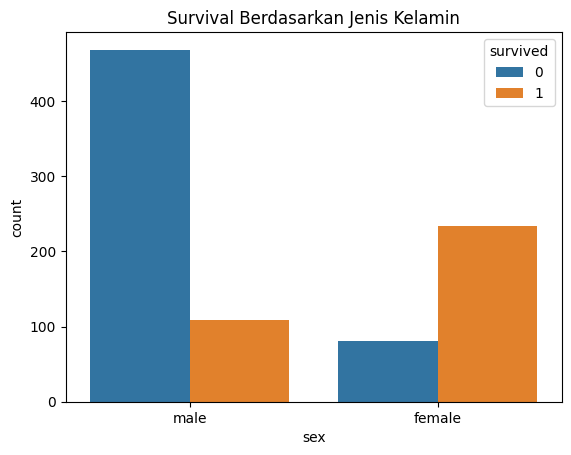

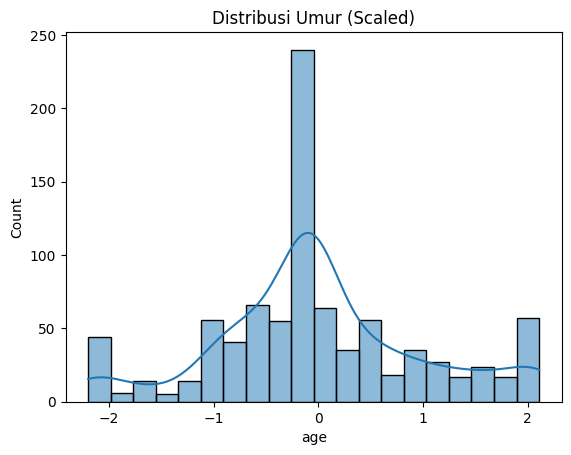

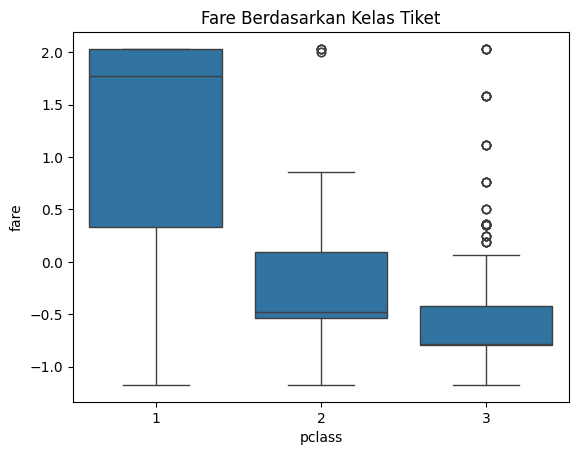

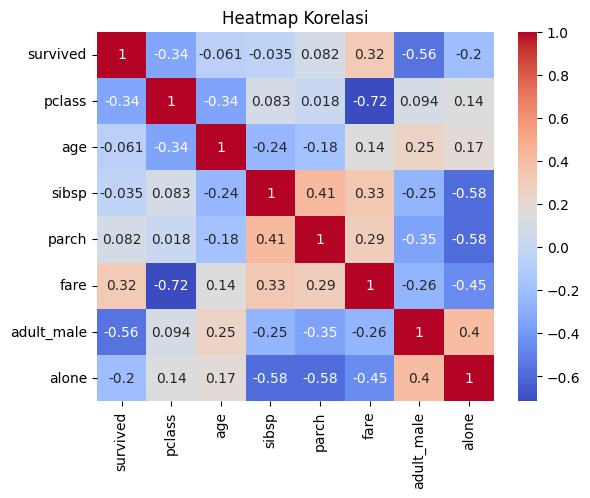

In [29]:
#Visualisasi (Minimal 5)

import seaborn as sns
import matplotlib.pyplot as plt

1#Survival Count
#Jumlah penumpang yang tidak selamat lebih banyak dibanding yang selamat.
plt.figure()
sns.countplot(x="survived", data=df)
plt.title("Jumlah Penumpang Selamat vs Tidak")
plt.show()

2#Survival Berdasarkan Jenis Kelamin
#Perempuan memiliki tingkat keselamatan jauh lebih tinggi dibanding laki-laki (prioritas evakuasi).
plt.figure()
sns.countplot(x="sex", hue="survived", data=df)
plt.title("Survival Berdasarkan Jenis Kelamin")
plt.show()

3#Distribusi Umur
#Mayoritas penumpang berada pada usia 20–40 tahun.
plt.figure()
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Distribusi Umur (Scaled)")
plt.show()

4#Fare Berdasarkan Kelas
#Penumpang kelas 1 membayar tiket lebih mahal dan memiliki peluang selamat lebih tinggi.
plt.figure()
sns.boxplot(x="pclass", y="fare", data=df)
plt.title("Fare Berdasarkan Kelas Tiket")
plt.show()

5#Heatmap Korelasi
#Terdapat korelasi:
         #Fare → positif terhadap survival
         #Pclass → negatif terhadap survival
         #Gender sangat berpengaruh terhadap keselamatan
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Heatmap Korelasi")
plt.show()